# Train and test I.A for model select

### Verify if the image is corrupted

In [ ]:
from utils.verifyImages import VerifyImages

VerifyImages(path='../imagens').verifyTrainAndTest()

### Import and create itens for train

In [2]:
import os 
from time import sleep
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
from tqdm import tqdm
from utils.customDataset import CustomDataset
from utils.loadDataset import TrainDatasetImplemetation
from utils.evaluationMetrics import Metrics
from utils.evaluationState import EvaluationState
from utils.models import ImagemDetectionModels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   

print("Dispositivo utilizado: ", device)

Dispositivo utilizado:  cpu


In [3]:
data_set_path = "../imagens"    

image_size = (224, 224)
batch_size = 32
data_set = TrainDatasetImplemetation(data_set_path, image_size, batch_size)
train_data = data_set.load_train_data(pin_memory=True)
test_data = data_set.load_test_data()


classes name: ['com_animal', 'sem_animal']
['com_animal', 'sem_animal']
no of samples in train dataset 2019


/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


train images shape: torch.Size([32, 3, 224, 224])
train labels: tensor([1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 1])
classes name: ['com_animal', 'sem_animal']
['com_animal', 'sem_animal']
no of samples in test dataset 2012
test images shape: tensor([[[[0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          ...,
          [0.9961, 0.9961, 0.9961,  ..., 0.9922, 0.9961, 0.9922],
          [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961]],

         [[0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
          ...,
          [0.9961, 0.9961, 0.9961,  ..., 0.9922, 0.9961, 0.9922],
     

In [4]:
# Define binary classficiation!
num_classes = 2
# Create the model implementation
model = ImagemDetectionModels.resnet50(num_classes)
# Pass model to the device
model = model.to(device)
# Train model 
model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
# Define the learnin rate
learning_rate = 1e-3
# Number of epochs
num_epochs = 100
'''
    Define the loss function for multi-class classification.
    CrossEntropyLoss combines LogSoftmax and Negative Log-Likelihood Loss (NLLLoss) in one single class.
    It expects raw, unnormalized logits as input and automatically applies softmax.
    The target should contain class indices (e.g., 0, 1, 2...) corresponding to the correct class.

    Internally, for each prediction:
    1. Applies softmax to convert logits into probabilities.
    2. Takes the log of the probability for the correct class.
    3. Applies the negative log to calculate the loss.
    Intuition:
    - If the model gives high probability to the correct class → low loss (good).
    - If the model gives low probability to the correct class → high loss (bad).
    Used for classification problems with two or more classes.
'''
criterion = nn.CrossEntropyLoss()
'''
    Define the optimizer to update the model's parameters during training.
    Adam (Adaptive Moment Estimation) is an optimization algorithm that combines
    the benefits of AdaGrad and RMSProp. It adapts the learning rate for each parameter
    using estimates of the first and second moments of the gradients.

    Arguments:
    - model.parameters(): passes all trainable parameters of the model to the optimizer.
    - lr=learning_rate: sets the initial learning rate for updating the weights.

    Adam is widely used because it typically converges faster and requires less tuning
    of the learning rate compared to traditional stochastic gradient descent (SGD).
'''
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Epoch 2: 100%|██████████| 64/64 [03:50<00:00,  3.60s/batch, loss=0.693]
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samp

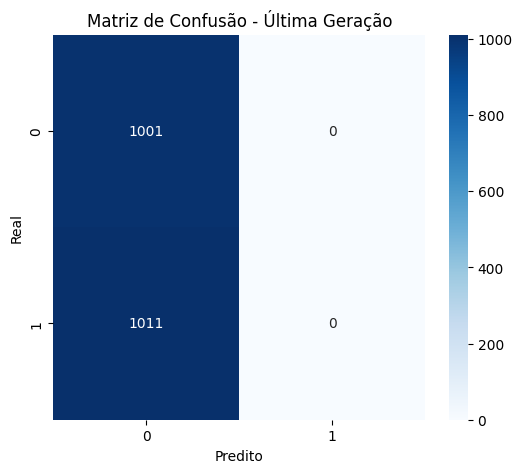

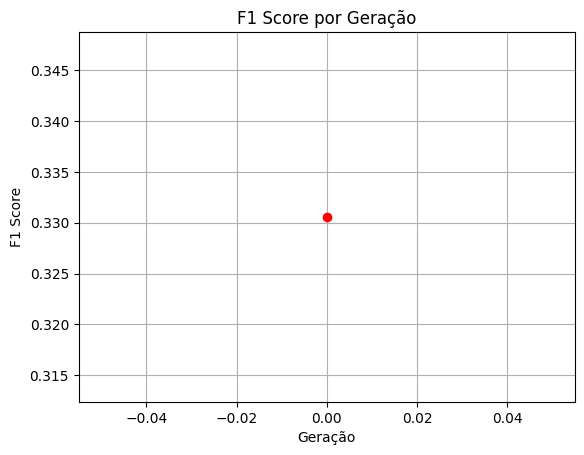

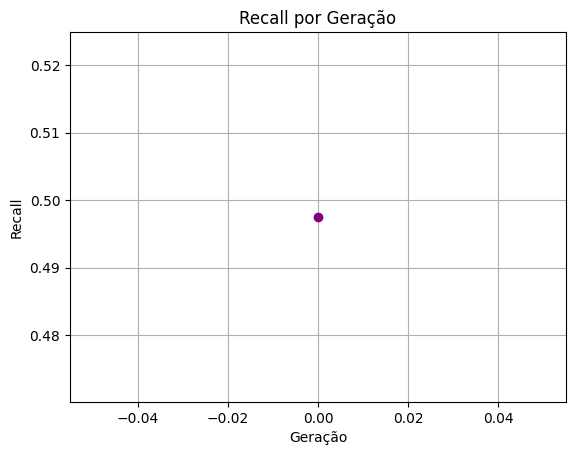

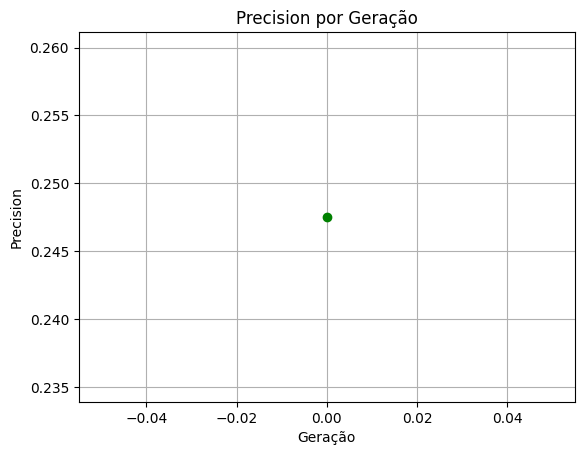

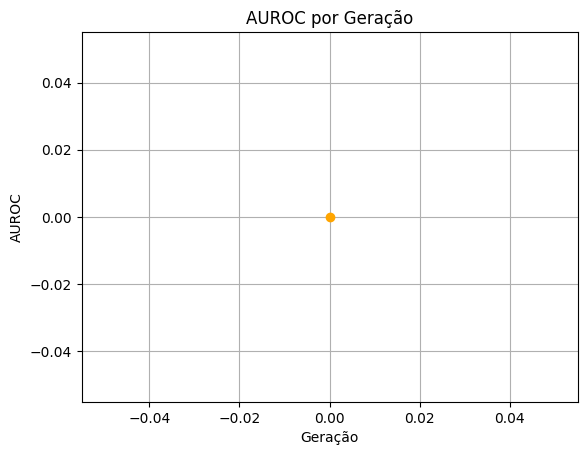

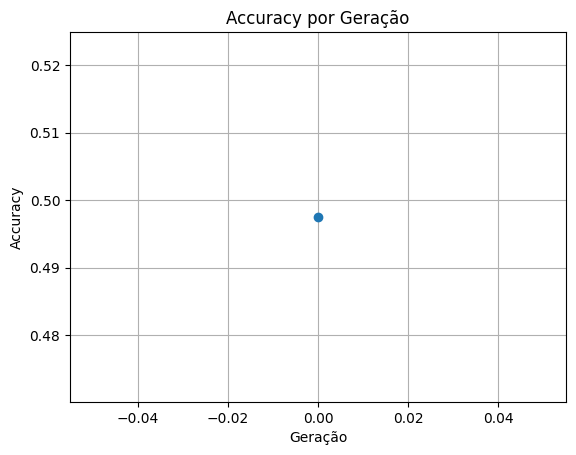

  0%|          | 0/64 [00:00<?, ?batch/s]/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 4: 100%|██████████| 64/64 [03:41<00:00,  3.45s/batch, loss=0.693]
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

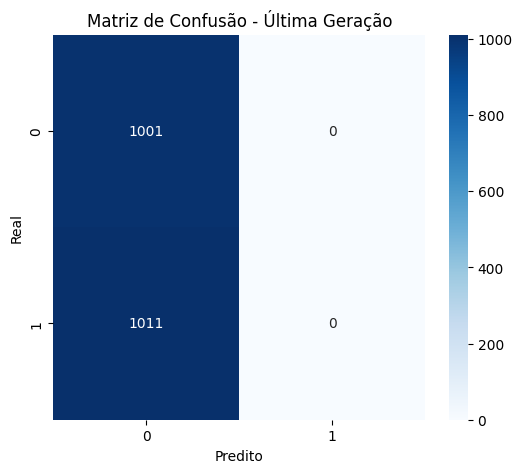

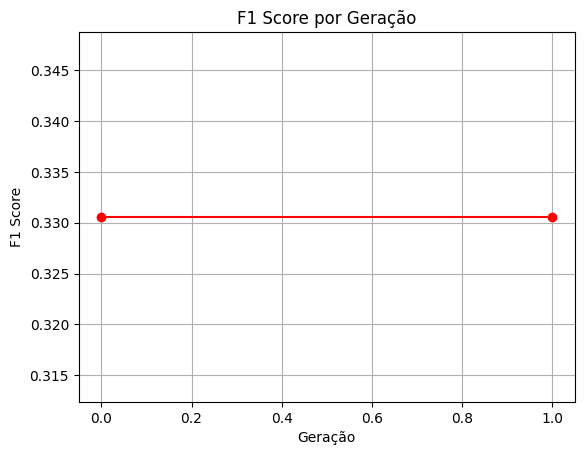

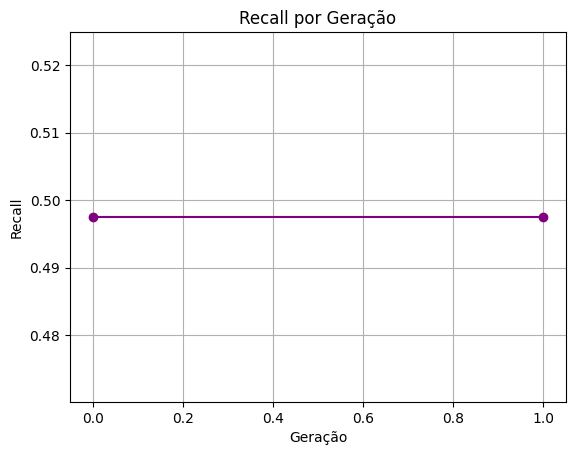

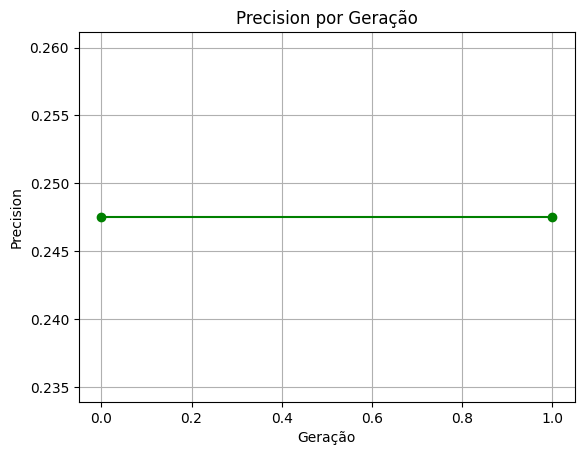

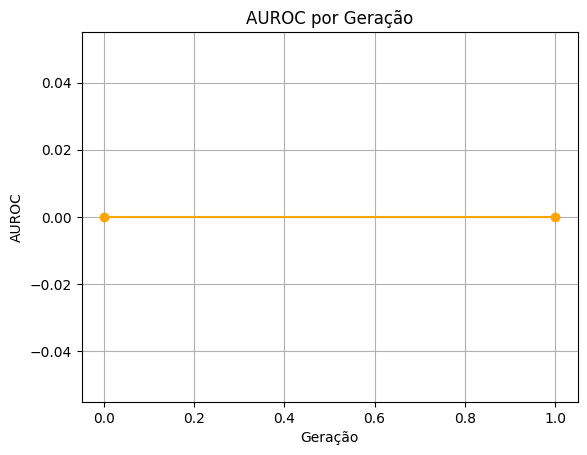

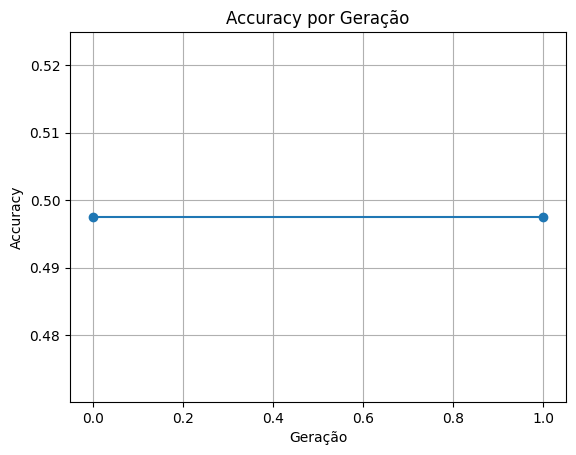

  0%|          | 0/64 [00:00<?, ?batch/s]/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 6: 100%|██████████| 64/64 [03:39<00:00,  3.43s/batch, loss=0.696]
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

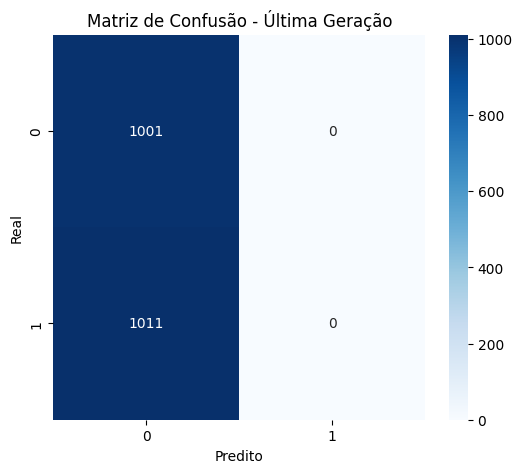

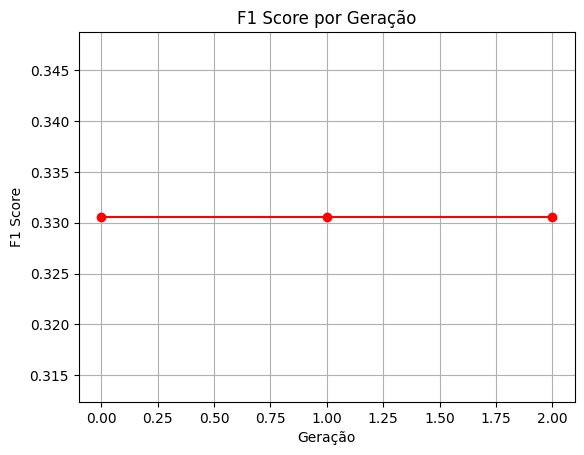

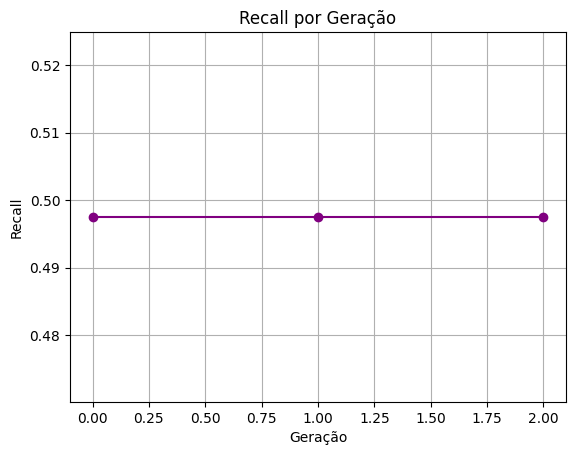

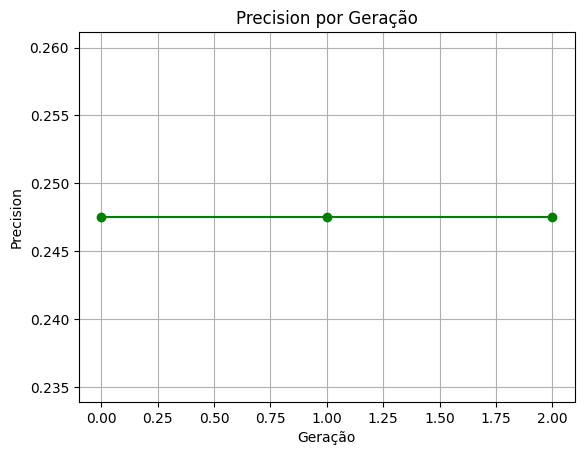

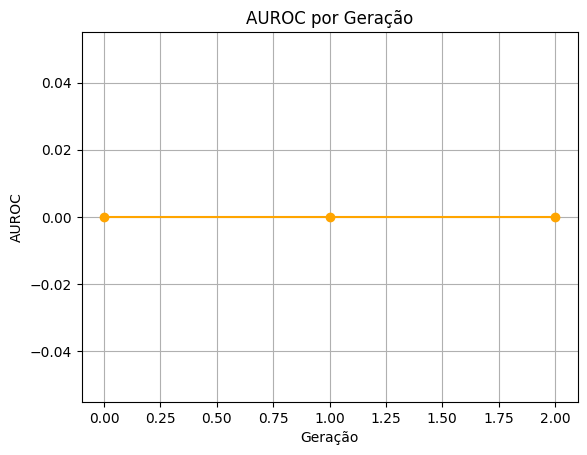

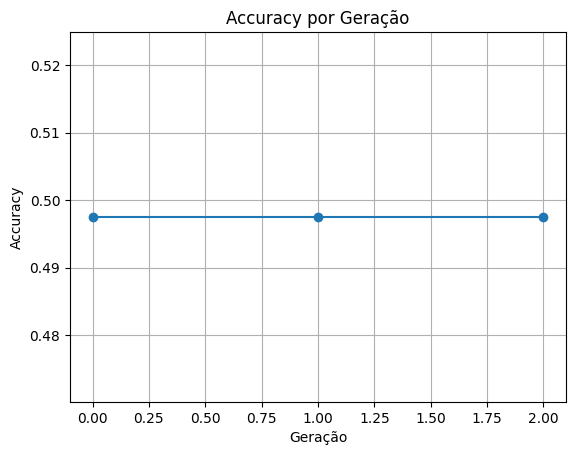

  0%|          | 0/64 [00:00<?, ?batch/s]/home/ltenir/ia/brazilian_animal_detection/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 8:  97%|█████████▋| 62/64 [03:41<00:07,  3.54s/batch, loss=0.72] 

In [ ]:
metrics = Metrics(model=model, device=device, test_data=test_data)
metricsStates = EvaluationState()

for epoch in range(1, num_epochs + 1):
    # Create a tqdm progress bar for visualizing training progress per batch
    pbar_batch = tqdm(train_data, unit="batch")
    losses = []
    # Iterate over each batch of data
    for data in pbar_batch:
        # Set the description of the progress bar to show current epoch

        pbar_batch.set_description(f"Epoch {epoch}")
        # Unpacking and sending to GPU
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        # raw scores before softmax
        scores = model(images)
        # We calculate the loss using criterion (CrossEntropyLoss).
        loss = criterion(scores, labels)
        losses.append(loss.item())
        cost = sum(losses)/len(losses)
        # Backward Pass and Weight Update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Updates the progress bar
        pbar_batch.set_postfix(loss=cost)
        sleep(0.1)

    if epoch % 2 == 0:
        metricsResult = metrics.colectMetrics()
        metricsStates.appendResult(metricsResult)
        metricsStates.plotConfusionMatrixLast()
        metricsStates.plotF1Score()
        metricsStates.plotRecall()
        metricsStates.plotPrecision()
        metricsStates.plotAuroc()
        metricsStates.plotAccuracy()
        sleep(0.1)


print("model training complete")

In [ ]:
'''
    saves the trained model weights to disk, creating the directory 
    if it does not already exist.
'''
model_save_path = "weights/resnet"
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

torch.save(model.state_dict(), model_save_path + "/resnet_model_checkpoint.pth")